In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns
from tqdm.notebook import tqdm
import h5py
import os

In [15]:
def Likelihood(y, dt, mu, theta, sigma, sigma_n):
    y = np.asarray(y, dtype=float)
    N = len(y)
    if theta <= 0 or sigma <= 0 or sigma_n <= 0:
        return -np.inf
    if N < 1:
        return -np.inf
    alpha = np.exp(-theta * dt)
    beta2 = (sigma**2 / (2.0 * theta)) * (1.0 - np.exp(-2.0 * theta * dt))
    m_filt = mu
    P_filt = sigma**2 / (2.0 * theta)
    loglik = 0.0
    # i=0 predictive for y0: N(m0, P0 + sigma_n^2)
    v0 = y[0] - m_filt
    S0 = P_filt + sigma_n**2
    if S0 <= 0 or not np.isfinite(S0):
        return -np.inf
    loglik += -0.5 * (np.log(2.0*np.pi) + np.log(S0) + (v0*v0)/S0)
    # update at i=0
    K0 = P_filt / S0
    m_filt = m_filt + K0 * v0
    P_filt = (1.0 - K0) * P_filt
    for i in range(1, N):
        # Predict
        m_pred = alpha * m_filt + (1.0 - alpha) * mu
        P_pred = alpha**2 * P_filt + beta2
        # Innovation
        v = y[i] - m_pred
        S = P_pred + sigma_n**2
        if S <= 0 or not np.isfinite(S):
            return -np.inf
        loglik += -0.5 * (np.log(2.0*np.pi) + np.log(S) + (v*v)/S)
        # Update
        K = P_pred / S
        m_filt = m_pred + K * v
        P_filt = (1.0 - K) * P_pred
    return loglik
def log_halfnormal_sigma_from_eta(eta, scale):
    s = np.exp(eta)
    return -0.5*(s/scale)**2 + eta 
def logprior_phi(phi, bounds=None):
    if bounds is None:
        return 0.0
    mu, eta_theta, eta_sigma, eta_n = phi
    if not (bounds['mu'][0] <= mu <= bounds['mu'][1]):
        return -np.inf
    if not (bounds['eta_theta'][0] <= eta_theta <= bounds['eta_theta'][1]):
        return -np.inf
    if not (bounds['eta_sigma'][0] <= eta_sigma <= bounds['eta_sigma'][1]):
        return -np.inf
    lp = 0.0
    lp += log_halfnormal_sigma_from_eta(eta_n, scale=0.05)
    return lp
def logpost_phi(phi, y, dt, bounds=None):
    mu, eta_theta, eta_sigma, eta_n = phi
    lp = logprior_phi(phi, bounds=bounds)
    if not np.isfinite(lp):
        return -np.inf
    theta = np.exp(eta_theta)
    sigma = np.exp(eta_sigma)
    sigma_n = np.exp(eta_n)
    ll = Likelihood(y, dt, mu, theta, sigma, sigma_n)
    if not np.isfinite(ll):
        return -np.inf
    return ll + lp 
def mh_samples_single(y, dt, phi0=None, prop_scales=None, bounds=None, n_steps=30000, rng=None):
    if phi0 is None:
        phi0 = np.array([1.0, np.log(0.7), np.log(0.240), np.log(0.005)], float)
    else:
        phi0 = np.array(phi0, float)
    if prop_scales is None:
        prop_scales = np.array([0.02, 0.06, 0.06, 0.06], float)
    else:
        prop_scales = np.array(prop_scales, float)
    phi = phi0.copy()
    logp = logpost_phi(phi, y, dt, bounds=bounds) 
    chain = np.zeros((n_steps, 4))
    logp_chain = np.zeros(n_steps)
    accepts = 0
    for k in range(n_steps):
        print(f"Step {k+1}/{n_steps}")
        chain[k] = phi
        logp_chain[k] = logp
        phi_star = phi + rng.normal(0.0, prop_scales, size=4)
        logp_star = logpost_phi(phi_star, y, dt, bounds=bounds)
        if np.isfinite(logp_star):
            log_r = logp_star - logp
            if np.log(rng.uniform()) < log_r:
                phi, logp = phi_star, logp_star
                accepts += 1
    acc_rate = accepts / float(n_steps)
    return chain, logp_chain, acc_rate
def chain_phi_to_theta(chain):
    mu = chain[:, 0]
    theta = np.exp(chain[:, 1])
    sigma = np.exp(chain[:, 2])
    sigma_n = np.exp(chain[:, 3])
    return mu, theta, sigma, sigma_n
def plot_traces(chain, true_mu, true_theta, true_sigma, true_sigma_n):
    mu, theta, sigma, sigma_n = chain_phi_to_theta(chain)
    fig, axs = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
    axs[0].plot(mu, lw=0.5)
    axs[0].axhline(true_mu, color="black", linestyle="--", linewidth=1)
    axs[0].set_ylabel("mu")
    axs[1].plot(theta, lw=0.5)
    axs[1].axhline(true_theta, color="black", linestyle="--", linewidth=1)
    axs[1].set_ylabel("theta")
    axs[2].plot(sigma, lw=0.5)
    axs[2].axhline(true_sigma, color="black", linestyle="--", linewidth=1)
    axs[2].set_ylabel("sigma")
    axs[3].plot(sigma_n, lw=0.5)
    axs[3].set_ylabel("sigma_n")
    axs[3].set_xlabel("iteration")
    plt.tight_layout()
    plt.show() 
def KalmanSmoother(y, dt, mu, theta, sigma, sigma_n):
    y = np.asarray(y, dtype=float)
    N = len(y)
    if theta <= 0 or sigma <= 0 or sigma_n <= 0:
        return None, None
    if N < 1:
        return None, None
    alpha = np.exp(-theta * dt)
    beta2 = (sigma**2 / (2.0 * theta)) * (1.0 - np.exp(-2.0 * theta * dt))
    M_filt = np.zeros(N)      # m_t|t
    P_filt_arr = np.zeros(N)  # P_t|t
    M_pred = np.zeros(N)      # m_t|t-1
    P_pred_arr = np.zeros(N)  # P_t|t-1
    m_now = mu
    P_now = sigma**2 / (2.0 * theta)
    M_pred[0] = m_now
    P_pred_arr[0] = P_now
    v0 = y[0] - m_now
    S0 = P_now + sigma_n**2
    K0 = P_now / S0
    m_now = m_now + K0 * v0
    P_now = (1.0 - K0) * P_now
    M_filt[0] = m_now
    P_filt_arr[0] = P_now
    for i in range(1, N):
        m_p = alpha * m_now + (1.0 - alpha) * mu
        P_p = alpha**2 * P_now + beta2
        M_pred[i] = m_p
        P_pred_arr[i] = P_p
        v = y[i] - m_p
        S = P_p + sigma_n**2
        K = P_p / S
        m_now = m_p + K * v
        P_now = (1.0 - K) * P_p
        M_filt[i] = m_now
        P_filt_arr[i] = P_now
    M_smooth = np.zeros(N)
    P_smooth = np.zeros(N)
    M_smooth[N-1] = M_filt[N-1]
    P_smooth[N-1] = P_filt_arr[N-1]
    for i in range(N-2, -1, -1):
        P_pred_next = P_pred_arr[i+1]
        J = (P_filt_arr[i] * alpha) / P_pred_next
        M_smooth[i] = M_filt[i] + J * (M_smooth[i+1] - M_pred[i+1])
        P_smooth[i] = P_filt_arr[i] + (J**2) * (P_smooth[i+1] - P_pred_next)
        
    return M_smooth, P_smooth
def rts_smoother(chain, y, dt, n_samples=1000):
    N = len(y)
    burn_in = 5000
    valid_chain = chain[burn_in:]
    indices = np.random.choice(len(valid_chain), size=n_samples, replace=False)
    selected_samples = valid_chain[indices]
    cloud_trajectories = np.zeros((n_samples, N))
    for i, phi in enumerate(selected_samples):
        m_smooth, _ = KalmanSmoother(y, dt, mu=phi[0], theta=np.exp(phi[1]), sigma=np.exp(phi[2]), sigma_n=np.exp(phi[3]))
        cloud_trajectories[i, :] = m_smooth
    posterior_mean = np.mean(cloud_trajectories, axis=0)
    return posterior_mean
def generate_and_plot_growth_cloud(chain, y, dt, n_samples=100, true_g=None):
    N = len(y)
    t = np.arange(N) * dt
    burn_in = 5000
    valid_chain = chain[burn_in:]
    indices = np.random.choice(len(valid_chain), size=n_samples, replace=False)
    selected_samples = valid_chain[indices]
    cloud_trajectories = np.zeros((n_samples, N))
    print(f"Reconstructing {n_samples} trajectories...")
    for i, phi in enumerate(selected_samples):
        mu_s, eta_theta_s, eta_sigma_s, eta_n_s = phi
        theta_s = np.exp(eta_theta_s)
        sigma_s = np.exp(eta_sigma_s)
        sigma_n_s = np.exp(eta_n_s)
        m_smooth, P_smooth = KalmanSmoother(y, dt, mu_s, theta_s, sigma_s, sigma_n_s)
        cloud_trajectories[i, :] = m_smooth
    cloud_std = np.std(cloud_trajectories, axis=0)
    avg_width = np.mean(cloud_std)
    print(f"Average Tube Width (Std Dev): {avg_width:.6f}")
    posterior_mean = np.mean(cloud_trajectories, axis=0) 
    plt.figure(figsize=(12, 7))
    plt.plot(t, cloud_trajectories.T, color='gray', alpha=0.5, linewidth=1)
    plt.plot(t, posterior_mean, color='blue', linewidth=2, label='Posterior Mean Estimate (g)') 
    plt.plot(t, y, 'g.', markersize=3, alpha=0.3, label='Noisy Data (y)')
    if true_g is not None:
        plt.plot(t, true_g, 'r--', linewidth=2, label='Ground Truth (g)')
    plt.fill_between(t, m_smooth - 1.96*np.sqrt(P_smooth), m_smooth + 1.96*np.sqrt(P_smooth), color='blue', alpha=0.2, label='95% Confidence')
    plt.title(f"Reconstructed Growth Rates (P(g|D))\nGenerated from {n_samples} MCMC samples")
    plt.xlabel("Time (hours)")
    plt.ylabel("Growth Rate (hour⁻¹)")
    cloud_proxy = mlines.Line2D([], [], color='black', alpha=0.5, label='Posterior Uncertainty Cloud')
    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(handles=[cloud_proxy] + handles, loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    #Zooming
    zoom_t_start = 3.0
    zoom_t_end = 3.5
    idx_start = int(zoom_t_start / dt)
    idx_end = int(zoom_t_end / dt)
    y_window = y[idx_start:idx_end]
    y_min = np.min(y_window)
    y_max = np.max(y_window)
    y_buffer = (y_max - y_min) * 0.15
    plt.xlim(zoom_t_start, zoom_t_end)
    plt.ylim(y_min - y_buffer, y_max + y_buffer)
    plt.show()
def moving_average(data, window_size):
    window = np.ones(window_size) / window_size
    return np.convolve(data, window, mode='same')
def plot_all_methods(chain, y, dt, true_g, n_samples=1000):
    my_best_estimate = rts_smoother(chain, y, dt, true_g, n_samples=1000)
    plt.figure(figsize=(14, 8))
    plt.plot(t, y, 'g.', markersize=3, alpha=0.15, label='Noisy Data')
    plt.plot(t, moving_average(y, 5), color='orange', linewidth=2, alpha=0.8, label='Moving Avg (Window=5)')
    plt.plot(t, moving_average(y, 9), color='brown', linewidth=2, alpha=0.8, label='Moving Avg (Window=9)')
    plt.plot(t, my_best_estimate, color='blue', linewidth=2.5, label='Bayesian Kalman Smoother (Yours)')
    plt.plot(t, true_g, 'r--', linewidth=2, label='Ground Truth')
    plt.title("Method Comparison: Bayesian Smoother vs. Moving Averages")
    plt.xlabel("Time (hours)")
    plt.ylabel("Growth Rate")
    plt.legend()
    plt.grid(True, alpha=0.3)
    zoom_t_start = 3.0
    zoom_t_end = 3.5
    idx_start = int(zoom_t_start / dt)
    idx_end = int(zoom_t_end / dt)
    y_window = y[idx_start:idx_end]
    y_min = np.min(y_window)
    y_max = np.max(y_window)
    y_buffer = (y_max - y_min) * 0.15
    plt.xlim(zoom_t_start, zoom_t_end)
    plt.ylim(y_min - y_buffer, y_max + y_buffer)
    plt.show()
def mh_samples_joint(Y, dt, phi0=None, prop_scales=None, bounds=None, n_steps=30000, rng=None, save_filename=None):    
    if phi0 is None:
        phi0 = np.array([1.0, np.log(0.7), np.log(0.240), np.log(0.005)], float)
    else:
        phi0 = np.array(phi0, float)
    if prop_scales is None:
        prop_scales = np.array([0.02, 0.06, 0.06, 0.06], float)
    else:
        prop_scales = np.array(prop_scales, float)
    def compute_joint_logp(phi_eval):
        total_logp = 0.0
        for y in Y:
            val = logpost_phi(phi_eval, y, dt, bounds=bounds)
            if not np.isfinite(val):
                return -np.inf
            total_logp += val
        return total_logp
    phi = phi0.copy()
    logp = compute_joint_logp(phi)
    chain = np.zeros((n_steps, 4))
    logp_chain = np.zeros(n_steps)
    accepts = 0
    pbar = tqdm(range(n_steps), desc="Joint MCMC")
    for k in pbar:
        if (k + 1) % 1000 == 0:
            pbar.set_postfix({'Log-P': f"{logp:.2f}"})
        chain[k] = phi
        logp_chain[k] = logp
        phi_star = phi + rng.normal(0.0, prop_scales, size=4)
        logp_star = compute_joint_logp(phi_star)
        if np.isfinite(logp_star):
            log_r = logp_star - logp
            if np.log(rng.uniform()) < log_r:
                phi, logp = phi_star, logp_star
                accepts += 1 
    acc_rate = accepts / float(n_steps)
    print(f"Finished! Acceptance rate: {acc_rate:.3f}")
    np.savez(save_filename, chain=chain, logp_chain=logp_chain, acc_rate=acc_rate)
    print(f"Success! Joint MCMC data safely saved to '{save_filename}'.")
    return chain, logp_chain, acc_rate
def plot_voilin_rmsd(Y, chain_single, chain_multi, G, dt, true_sigma_noise, save_filename="msd_results.csv"):
    N_traj = len(Y)        
    windows = [3, 5, 7, 15, 50, 75, 100, 150, 1000]
    results_final = []
    for i in tqdm(range(N_traj), desc="Calculating MSDs"):
        msd_noisy = np.sqrt(np.mean((Y[i] - G[i])**2))
        results_final.append({'Method': 'Raw Data', 'MSD': msd_noisy})
        chain_i = chain_single[i]
        est_bayes_single = rts_smoother(chain_i, Y[i], dt, n_samples=1000)
        msd_bayes_single = np.sqrt(np.mean((est_bayes_single - G[i])**2))
        results_final.append({'Method': 'Bayesian', 'MSD': msd_bayes_single})
        est_bayes_multi = rts_smoother(chain_multi, Y[i], dt, n_samples=1000)
        msd_bayes_multi = np.sqrt(np.mean((est_bayes_multi - G[i])**2))
        results_final.append({'Method': 'Bayesian Multi', 'MSD': msd_bayes_multi})
        for w in windows:
            est_ma = moving_average(Y[i], w)
            msd_w = np.sqrt(np.mean((est_ma - G[i])**2))
            results_final.append({'Method': f'MA-{w}', 'MSD': msd_w})
            
    print("Simulation and MSD calculations complete. Ready for plotting.")
    
    df = pd.DataFrame(results_final)
    df.to_csv(save_filename, index=False)
    print(f"Success! Data securely saved to '{save_filename}'.")
    method_order = ['Raw Data']  + ['Bayesian'] + ['Bayesian Multi'] + [f'MA-{w}' for w in windows]
    plt.figure(figsize=(12, 7))
    sns.violinplot(
        x='Method', 
        y='MSD', 
        data=df, 
        order=method_order,
        inner="point",      
        palette="coolwarm",
        cut=0               
    )
    plt.axhline(
        y=true_sigma_noise, 
        color='black', 
        linestyle='--', 
        linewidth=2, 
        label=f'True Machine Noise (sigma_n = {true_sigma_noise})',
        zorder=5
    )
    plt.title(f"Performance Comparison: Mean Square Deviation over {N_traj} Simulations", fontsize=14, fontweight='bold')
    plt.ylabel("Mean Square Deviation (MSD) vs. Truth", fontsize=12)
    plt.xlabel("Estimation Method", fontsize=12)
    plt.yscale('log')
    plt.grid(True, which="major", ls="-", alpha=0.3)
    plt.grid(True, which="minor", ls=":", alpha=0.2)
    plt.xticks(rotation=45)
    plt.legend(loc='upper right') 
    plt.tight_layout()
    plt.show()
def computing_single_chains(Y, dt, phi0=None, bounds=None, prop_scales=None, n_steps=30000, rng=None, save_filename="single_mcmc_results.npz"):
    all_chains = []
    all_acc_rates = []
    all_logp_chains = [] 
    N_traj = len(Y)
    for i in tqdm(range(N_traj), desc="Computing Single Chains"):
        chain, logp_chain, acc_rate = mh_samples_single(Y[i], dt, phi0=phi0, bounds=bounds, prop_scales=prop_scales, n_steps=n_steps, rng=rng)
        all_chains.append(chain)
        all_logp_chains.append(logp_chain)
        all_acc_rates.append(acc_rate)
    all_chains_arr = np.array(all_chains)
    all_logp_chains_arr = np.array(all_logp_chains)
    all_acc_rates_arr = np.array(all_acc_rates)
    np.savez(save_filename, chain_single=all_chains_arr, logp_single=all_logp_chains_arr, acc_rate_single=all_acc_rates_arr)
    print(f"Success! {N_traj} independent MCMC chains safely saved to '{save_filename}'.")
    return all_chains_arr
def plot_traces_grid_single(chain_list, rows, cols):
    N_traj = len(chain_list)
    if rows * cols < N_traj:
        raise ValueError(f"A {rows}x{cols} grid only holds {rows*cols} trajectories, but you have {N_traj}.")
    print(f"Plotting {N_traj} chains in a {rows}x{cols} grid (Total subplots: {rows * 4}x{cols})...")
    fig, axs = plt.subplots(rows * 4, cols, figsize=(cols * 5, rows * 6), squeeze=False)
    for i in range(rows * cols):
        r = i // cols
        c = i % cols
        ax_mu = axs[r * 4 + 0, c]
        ax_theta = axs[r * 4 + 1, c]
        ax_sigma = axs[r * 4 + 2, c]
        ax_sigman = axs[r * 4 + 3, c]
        if i < N_traj:
            mu, theta, sigma, sigma_n = chain_phi_to_theta(chain_list[i])
            mean_mu = np.mean(mu)
            mean_theta = np.mean(theta)
            mean_sigma = np.mean(sigma)
            mean_sigma_n = np.mean(sigma_n)
            ax_mu.plot(mu, lw=0.5, color='C0')
            ax_mu.axhline(mean_mu, color="black", linestyle="--", linewidth=1.5)
            ax_mu.set_title(f"Trajectory {i+1} MCMC Chains", fontweight='bold')
            if c == 0: ax_mu.set_ylabel("mu")

            ax_theta.plot(theta, lw=0.5, color='C1')
            ax_theta.axhline(mean_theta, color="black", linestyle="--", linewidth=1.5)
            if c == 0: ax_theta.set_ylabel("theta")
            
            ax_sigma.plot(sigma, lw=0.5, color='C2')
            ax_sigma.axhline(mean_sigma, color="black", linestyle="--", linewidth=1.5)
            if c == 0: ax_sigma.set_ylabel("sigma")
            
            ax_sigman.plot(sigma_n, lw=0.5, color='C3')
            ax_sigma.axhline(mean_sigma_n, color="black", linestyle="--", linewidth=1.5)
            if c == 0: ax_sigman.set_ylabel("sigma_n")
            ax_sigman.set_xlabel("Iteration")

            ax_mu.tick_params(labelbottom=False)
            ax_theta.tick_params(labelbottom=False)
            ax_sigma.tick_params(labelbottom=False)
            
        else:
            ax_mu.axis('off')
            ax_theta.axis('off')
            ax_sigma.axis('off')
            ax_sigman.axis('off')
            
    plt.tight_layout()
    plt.show()
def plot_traces_joint_MCMC(chain, caption=None):
    mu, theta, sigma, sigma_n = chain_phi_to_theta(chain)
    mean_mu = np.mean(mu)
    mean_theta = np.mean(theta)
    mean_sigma = np.mean(sigma)
    mean_sigma_n = np.mean(sigma_n)
    fig, axs = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
    axs[0].plot(mu, lw=0.5, color='C0')
    axs[0].axhline(mean_mu, color="black", linestyle="--", linewidth=1.5)
    axs[0].set_ylabel("mu", fontweight='bold')
    axs[1].plot(theta, lw=0.5, color='C1')
    axs[1].axhline(mean_theta, color="black", linestyle="--", linewidth=1.5)
    axs[1].set_ylabel("theta", fontweight='bold')
    axs[2].plot(sigma, lw=0.5, color='C2')
    axs[2].axhline(mean_sigma, color="black", linestyle="--", linewidth=1.5)
    axs[2].set_ylabel("sigma", fontweight='bold')
    axs[3].plot(sigma_n, lw=0.5, color='C3')
    axs[3].axhline(mean_sigma_n, color="black", linestyle="--", linewidth=1.5, label=f'Mean: {mean_sigma_n:.4f}')
    axs[3].set_ylabel("sigma_n", fontweight='bold')
    axs[3].set_xlabel("MCMC Iteration")
    fig.suptitle("Joint MCMC Convergence Traces", fontsize=16, fontweight='bold', y=0.97)
    plt.tight_layout()
    if caption:
        plt.subplots_adjust(bottom=0.12)
        fig.text(0.5, 0.02, caption, wrap=True, horizontalalignment='center', 
                 fontsize=11, style='italic', color='dimgrey')    
    plt.show()
def plot_cloud_grid_single(chain_list, Y, true_G, dt, rows, cols, n_samples=100, zoom_t_start=3.0, zoom_t_end=3.5):
    N_traj = len(Y)
    if rows * cols < N_traj:
        raise ValueError(f"A {rows}x{cols} grid only holds {rows*cols} plots, but you have {N_traj}.")
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4), squeeze=False)
    axes = axes.flatten()
    t = np.arange(len(Y[0])) * dt
    idx_start = int(zoom_t_start / dt)
    idx_end = int(zoom_t_end / dt)
    burn_in = 5000

    for i in tqdm(range(rows * cols), desc="Generating Single MCMC Clouds"):
        ax = axes[i]
        if i < N_traj:
            y = Y[i]
            true_g = true_G[i]
            chain = chain_list[i]
            
            valid_chain = chain[burn_in:]
            indices = np.random.choice(len(valid_chain), size=n_samples, replace=False)
            selected_samples = valid_chain[indices]
            
            cloud_trajectories = np.zeros((n_samples, len(y)))
            
            for j, phi in enumerate(selected_samples):
                mu_s, eta_theta_s, eta_sigma_s, eta_n_s = phi
                theta_s, sigma_s, sigma_n_s = np.exp(eta_theta_s), np.exp(eta_sigma_s), np.exp(eta_n_s)
                
                m_smooth, P_smooth = KalmanSmoother(y, dt, mu_s, theta_s, sigma_s, sigma_n_s)
                cloud_trajectories[j, :] = m_smooth
                
            posterior_mean = np.mean(cloud_trajectories, axis=0) 
            
            ax.plot(t, cloud_trajectories.T, color='gray', alpha=0.5, lw=1)
            ax.plot(t, posterior_mean, color='blue', lw=2, label='Posterior Mean') 
            ax.plot(t, y, 'g.', markersize=3, alpha=0.3, label='Noisy Data (y)')
            
            if true_G is not None:
                ax.plot(t, true_g, 'r--', lw=2, label='Ground Truth')
                
            ax.fill_between(t, m_smooth - 1.96*np.sqrt(P_smooth), m_smooth + 1.96*np.sqrt(P_smooth), color='blue', alpha=0.2)
            
            y_window = y[idx_start:idx_end]
            y_buffer = (np.max(y_window) - np.min(y_window)) * 0.15
            ax.set_xlim(zoom_t_start, zoom_t_end)
            ax.set_ylim(np.min(y_window) - y_buffer, np.max(y_window) + y_buffer)
            
            ax.set_title(f"Cell {i+1} (Single MCMC)", fontweight='bold')
            ax.set_xlabel("Time (hours)")
            if i % cols == 0: ax.set_ylabel("Growth Rate")
            
            if i == 0:
                cloud_proxy = mlines.Line2D([], [], color='gray', alpha=0.5, label='Uncertainty Cloud')
                handles, _ = ax.get_legend_handles_labels()
                ax.legend(handles=[cloud_proxy] + handles, loc='best', fontsize=8)
                
        else:
            ax.axis('off')

    plt.tight_layout()
    plt.show()
def plot_cloud_grid_joint(chain, Y, true_G, dt, rows, cols, n_samples=100, zoom_t_start=3.0, zoom_t_end=3.5):
    N_traj = len(Y)
    if rows * cols < N_traj:
        raise ValueError(f"A {rows}x{cols} grid only holds {rows*cols} plots, but you have {N_traj}.")
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4), squeeze=False)
    axes = axes.flatten()
    t = np.arange(len(Y[0])) * dt
    idx_start = int(zoom_t_start / dt)
    idx_end = int(zoom_t_end / dt)
    
    burn_in = 5000
    valid_chain = chain[burn_in:]
    indices = np.random.choice(len(valid_chain), size=n_samples, replace=False)
    selected_samples = valid_chain[indices]

    for i in tqdm(range(rows * cols), desc="Generating Joint MCMC Clouds"):
        ax = axes[i]
        
        if i < N_traj:
            y = Y[i]
            true_g = true_G[i]
            
            cloud_trajectories = np.zeros((n_samples, len(y)))
            
            for j, phi in enumerate(selected_samples):
                mu_s, eta_theta_s, eta_sigma_s, eta_n_s = phi
                theta_s, sigma_s, sigma_n_s = np.exp(eta_theta_s), np.exp(eta_sigma_s), np.exp(eta_n_s)
                
                m_smooth, P_smooth = KalmanSmoother(y, dt, mu_s, theta_s, sigma_s, sigma_n_s)
                cloud_trajectories[j, :] = m_smooth
                
            posterior_mean = np.mean(cloud_trajectories, axis=0) 
            
            ax.plot(t, cloud_trajectories.T, color='gray', alpha=0.5, lw=1)
            ax.plot(t, posterior_mean, color='blue', lw=2, label='Posterior Mean') 
            ax.plot(t, y, 'g.', markersize=3, alpha=0.3, label='Noisy Data (y)')
            
            if true_G is not None:
                ax.plot(t, true_g, 'r--', lw=2, label='Ground Truth')
                
            ax.fill_between(t, m_smooth - 1.96*np.sqrt(P_smooth), m_smooth + 1.96*np.sqrt(P_smooth), color='blue', alpha=0.2)
            
            y_window = y[idx_start:idx_end]
            y_buffer = (np.max(y_window) - np.min(y_window)) * 0.15
            ax.set_xlim(zoom_t_start, zoom_t_end)
            ax.set_ylim(np.min(y_window) - y_buffer, np.max(y_window) + y_buffer)
            
            ax.set_title(f"Cell {i+1} (Joint MCMC)", fontweight='bold')
            ax.set_xlabel("Time (hours)")
            if i % cols == 0: ax.set_ylabel("Growth Rate")
            
            if i == 0:
                cloud_proxy = mlines.Line2D([], [], color='gray', alpha=0.5, label='Uncertainty Cloud')
                handles, _ = ax.get_legend_handles_labels()
                ax.legend(handles=[cloud_proxy] + handles, loc='best', fontsize=8)
                
        else:
            ax.axis('off')

    plt.tight_layout()
    plt.show()
def plot_all_methods_single(chain_list, Y, true_G, dt, rows, cols, n_samples=1000, zoom_t_start=3.0, zoom_t_end=3.5):
    N_traj = len(Y)
    if rows * cols < N_traj:
        raise ValueError(f"A {rows}x{cols} grid only holds {rows*cols} plots, but you have {N_traj}.")

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4), squeeze=False)
    axes = axes.flatten()
    
    t = np.arange(len(Y[0])) * dt
    idx_start = int(zoom_t_start / dt)
    idx_end = int(zoom_t_end / dt)

    for i in tqdm(range(rows * cols), desc="Comparing Single Methods"):
        ax = axes[i]
        
        if i < N_traj:
            y = Y[i]
            true_g = true_G[i]
            chain = chain_list[i]
            
            my_best_estimate = rts_smoother(chain, y, dt, n_samples=n_samples)
            
            ax.plot(t, y, 'g.', markersize=3, alpha=0.15, label='Noisy Data')
            ax.plot(t, moving_average(y, 5), color='orange', linewidth=2, alpha=0.8, label='MA (Window=5)')
            ax.plot(t, moving_average(y, 9), color='brown', linewidth=2, alpha=0.8, label='MA (Window=9)')
            ax.plot(t, my_best_estimate, color='blue', linewidth=2.5, label='Bayesian Smoother')
            
            if true_G is not None:
                ax.plot(t, true_g, 'r--', linewidth=2, label='Ground Truth')
            
            y_window = y[idx_start:idx_end]
            y_buffer = (np.max(y_window) - np.min(y_window)) * 0.15
            ax.set_xlim(zoom_t_start, zoom_t_end)
            ax.set_ylim(np.min(y_window) - y_buffer, np.max(y_window) + y_buffer)
            
            ax.set_title(f"Cell {i+1} Comparison", fontweight='bold')
            ax.set_xlabel("Time (hours)")
            if i % cols == 0: ax.set_ylabel("Growth Rate")
            ax.grid(True, alpha=0.3)
            
            if i == 0:
                ax.legend(loc='best', fontsize=8)
                
        else:
            ax.axis('off')

    plt.tight_layout()
    plt.show()
def plot_all_methods_joint(chain, Y, true_G, dt, rows, cols, n_samples=1000, zoom_t_start=3.0, zoom_t_end=3.5):
    N_traj = len(Y)
    if rows * cols < N_traj:
        raise ValueError(f"A {rows}x{cols} grid only holds {rows*cols} plots, but you have {N_traj}.")

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4), squeeze=False)
    axes = axes.flatten()
    
    t = np.arange(len(Y[0])) * dt
    idx_start = int(zoom_t_start / dt)
    idx_end = int(zoom_t_end / dt)

    for i in tqdm(range(rows * cols), desc="Comparing Joint Methods"):
        ax = axes[i]
        
        if i < N_traj:
            y = Y[i]
            true_g = true_G[i]
            
            my_best_estimate = rts_smoother(chain, y, dt, n_samples=n_samples)

            ax.plot(t, y, 'g.', markersize=3, alpha=0.15, label='Noisy Data')
            ax.plot(t, moving_average(y, 5), color='orange', linewidth=2, alpha=0.8, label='MA (Window=5)')
            ax.plot(t, moving_average(y, 9), color='brown', linewidth=2, alpha=0.8, label='MA (Window=9)')
            ax.plot(t, my_best_estimate, color='blue', linewidth=2.5, label='Joint Bayesian Smoother')
            
            if true_G is not None:
                ax.plot(t, true_g, 'r--', linewidth=2, label='Ground Truth')
            
            y_window = y[idx_start:idx_end]
            y_buffer = (np.max(y_window) - np.min(y_window)) * 0.15
            ax.set_xlim(zoom_t_start, zoom_t_end)
            ax.set_ylim(np.min(y_window) - y_buffer, np.max(y_window) + y_buffer)
            
            ax.set_title(f"Cell {i+1} Comparison", fontweight='bold')
            ax.set_xlabel("Time (hours)")
            if i % cols == 0: ax.set_ylabel("Growth Rate")
            ax.grid(True, alpha=0.3)
            
            if i == 0:
                ax.legend(loc='best', fontsize=8)
                
        else:
            ax.axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
def load_data(filepath='growth_rates.nc'):
    with h5py.File(filepath, 'r') as f:
        time_hours = f['frame'][:]
        gr_area = f['growth_rate_area'][:]      
        gr_length = f['growth_rate_length'][:]  
        division = f['division'][:]
        smoothing_windows = f['smoothing'][:]
    dt = time_hours[1] - time_hours[0]
    div_indices = np.where(division == 1)[0]
    gr_area_split_all = []
    gr_length_split_all = []
    
    for i in range(len(smoothing_windows)):
        area_splits = np.split(gr_area[i], div_indices)
        area_cleaned = [traj[1:] for traj in area_splits if len(traj) > 10]
        gr_area_split_all.append(area_cleaned)
        length_splits = np.split(gr_length[i], div_indices)
        length_cleaned = [traj[1:] for traj in length_splits if len(traj) > 10]
        gr_length_split_all.append(length_cleaned)
        
    fig, axes = plt.subplots(1, 5, figsize=(20, 5), sharey=True)
    
    for i, ax in enumerate(axes):
        ax.plot(time_hours, gr_length[i], color='orange', alpha=0.6, linewidth=1, label='Length GR')
        ax.plot(time_hours, gr_area[i], color='blue', alpha=0.8, linewidth=1.5, label='Area GR')
        
        for j, idx in enumerate(div_indices):
            label = 'Division' if j == 0 else ""
            ax.axvline(time_hours[idx], color='red', linestyle='--', alpha=0.5, label=label)
            
        ax.set_title(f"Smoothing Window = {smoothing_windows[i]}", fontweight='bold')
        ax.set_xlabel("Time (hours)")
        if i == 0:
            ax.set_ylabel("Growth Rate (1/h)")
            ax.legend(loc='upper right', fontsize=8)
        ax.grid(True, linestyle=':', alpha=0.6)

    caption = (
        "Figure 1: Comparison of Area-based vs Length-based growth rates over 1000 continuous frames. "
        "Each column displays a different moving average smoothing window applied by DeLTA. "
        "Vertical red lines denote cell division events. Length-based rates (orange) "
        "exhibit significantly higher high-frequency noise compared to area-based rates (blue)."
    )
    plt.subplots_adjust(bottom=0.25, top=0.85)
    fig.text(0.5, 0.05, caption, wrap=True, horizontalalignment='center', fontsize=12, style='italic', color='dimgrey')
    plt.suptitle("Experimental Cell Growth Rates: The Impact of Smoothing and Measurement Choice", fontweight='bold', fontsize=16)
    plt.show()
    
    print(f"Time step (dt): {dt:.4f} hours")
    print(f"Number of smoothing windows extracted: {len(gr_area)}")
    print(f"Number of independent cell trajectories (after splitting): {len(gr_area_split_all[0])}")
    
    return {
        'dt': dt,
        'time_hours': time_hours,
        'smoothing_windows': smoothing_windows,
        'continuous_area': gr_area,
        'continuous_length': gr_length,
        'split_area': gr_area_split_all,
        'split_length': gr_length_split_all
    }

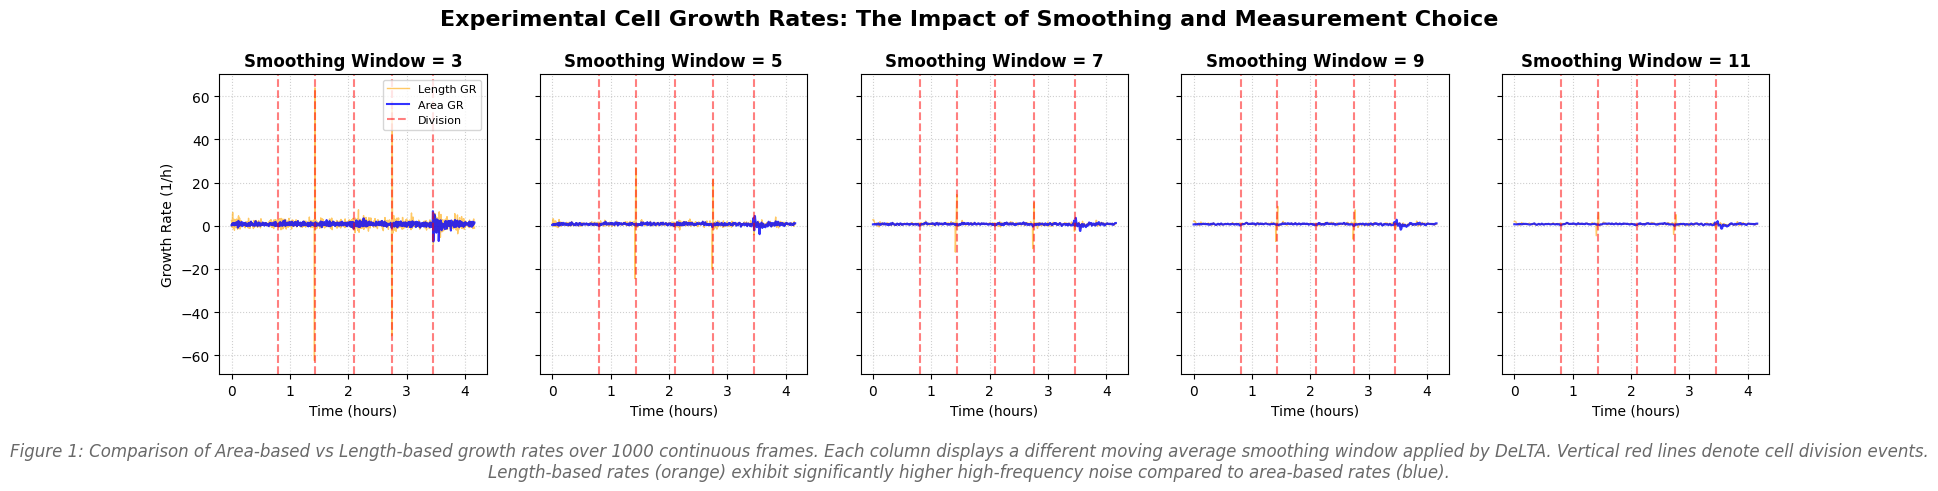

Time step (dt): 0.0042 hours
Number of smoothing windows extracted: 5
Number of independent cell trajectories (after splitting): 6


In [3]:
real_data = load_data('growth_rates.nc')

In [17]:
bounds = {"mu": (0.6, 2.0),"eta_theta": (np.log(0.5), np.log(1.5)),
          "eta_sigma": (np.log(1e-4), np.log(1.5)),"eta_n":(np.log(1e-4), np.log(1.5)),}
prop_scales = np.array([0.02, 0.04, 0.04, 0.04], float)
phi0 = np.array([1.0, np.log(0.7), np.log(0.5), np.log(0.5)], float) 

In [7]:
rng_mcmc = np.random.RandomState(1234567)

In [13]:
dt_real = real_data['dt']
Y_real_area = real_data['split_area'][0]

In [20]:
chain_real, logp_real, acc_real = mh_samples_joint(Y=Y_real_area, dt=dt_real, phi0=phi0, prop_scales=prop_scales,bounds=bounds, n_steps=50000, rng=rng_mcmc,save_filename="First try on real data joint mcmc.npz")

Joint MCMC:   0%|          | 0/50000 [00:00<?, ?it/s]

Finished! Acceptance rate: 0.337
Success! Joint MCMC data safely saved to 'First try on real data joint mcmc.npz'.


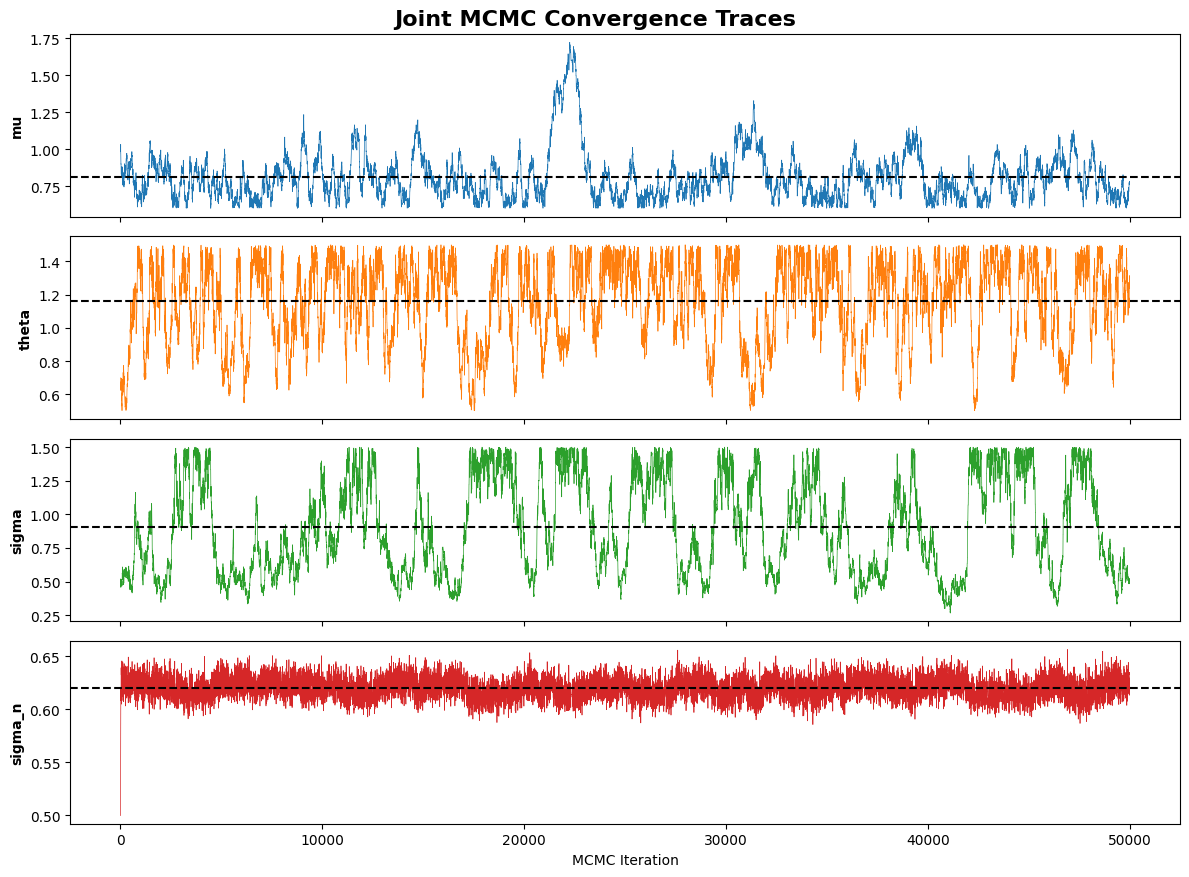

In [21]:
plot_traces_joint_MCMC(chain_real)

In [23]:
bounds = {"mu": (0.26, 2.0),"eta_theta": (np.log(0.25), np.log(2.0)),
          "eta_sigma": (np.log(1e-4), np.log(2.0)),"eta_n":(np.log(1e-4), np.log(1.5)),}
prop_scales = np.array([0.02, 0.04, 0.04, 0.04], float)
phi0 = np.array([1.0, np.log(0.7), np.log(0.5), np.log(0.5)], float) 

In [22]:
def joint_mcmc_chains_all_trajectories(split_area_all, split_length_all, smoothing_windows, dt, phi0, prop_scales, bounds, n_steps=50000, rng=None):
    mcmc_results = {
        'Area': {},
        'Length': {}
    }
    print(f"Starting {2 * len(smoothing_windows)} independent Joint MCMC runs...")
    for i, window in enumerate(tqdm(smoothing_windows, desc="Evaluating Smoothing Windows")):
        print(f"\n========== SMOOTHING WINDOW: {window} ==========")
        Y_area = split_area_all[i]
        save_name_area = f"Experimental_Area_Joint_MCMC_window_{window}.npz"
        print(f"-> Running Area Data (Saving to {save_name_area})...") 
        chain_a, logp_a, acc_a = mh_samples_joint(
            Y=Y_area, 
            dt=dt, 
            phi0=phi0, 
            prop_scales=prop_scales, 
            bounds=bounds, 
            n_steps=n_steps, 
            rng=rng,
            save_filename=save_name_area
        )
        mcmc_results['Area'][window] = {
            'chain': chain_a,
            'logp': logp_a,
            'acc_rate': acc_a
        }
        Y_length = split_length_all[i]
        save_name_length = f"Experimental_Length_Joint_MCMC_window_{window}.npz"
        print(f"-> Running Length Data (Saving to {save_name_length})...")
        chain_l, logp_l, acc_l = mh_samples_joint(
            Y=Y_length, 
            dt=dt, 
            phi0=phi0, 
            prop_scales=prop_scales, 
            bounds=bounds, 
            n_steps=n_steps, 
            rng=rng,
            save_filename=save_name_length
        )
        mcmc_results['Length'][window] = {
            'chain': chain_l,
            'logp': logp_l,
            'acc_rate': acc_l
        }
    print("\nSuccess! All experimental Joint MCMC chains computed and securely saved.")
    return mcmc_results

In [24]:
smoothing_windows = real_data['smoothing_windows']
Y_area_all = real_data['split_area']
Y_length_all = real_data['split_length']
dt_real = real_data['dt']

In [25]:
print("Initiating the master Joint MCMC pipeline...")
experimental_mcmc_results = joint_mcmc_chains_all_trajectories(split_area_all=Y_area_all, split_length_all=Y_length_all, smoothing_windows=smoothing_windows, dt=dt_real, phi0=phi0, prop_scales=prop_scales, bounds=bounds, n_steps=50000, rng=rng_mcmc)

Initiating the master Joint MCMC pipeline...
Starting 10 independent Joint MCMC runs...


Evaluating Smoothing Windows:   0%|          | 0/5 [00:00<?, ?it/s]


========== SMOOTHING WINDOW: 3 ==========
-> Running Area Data (Saving to Experimental_Area_Joint_MCMC_window_3.npz)...


Joint MCMC:   0%|          | 0/50000 [00:00<?, ?it/s]

Finished! Acceptance rate: 0.274
Success! Joint MCMC data safely saved to 'Experimental_Area_Joint_MCMC_window_3.npz'.
-> Running Length Data (Saving to Experimental_Length_Joint_MCMC_window_3.npz)...


...

Finished! Acceptance rate: 0.051
Success! Joint MCMC data safely saved to 'Experimental_Length_Joint_MCMC_window_9.npz'.

========== SMOOTHING WINDOW: 11 ==========
-> Running Area Data (Saving to Experimental_Area_Joint_MCMC_window_11.npz)...


Joint MCMC:   0%|          | 0/50000 [00:00<?, ?it/s]

Finished! Acceptance rate: 0.487
Success! Joint MCMC data safely saved to 'Experimental_Area_Joint_MCMC_window_11.npz'.
-> Running Length Data (Saving to Experimental_Length_Joint_MCMC_window_11.npz)...


Joint MCMC:   0%|          | 0/50000 [00:00<?, ?it/s]

Finished! Acceptance rate: 0.044
Success! Joint MCMC data safely saved to 'Experimental_Length_Joint_MCMC_window_11.npz'.

Success! All experimental Joint MCMC chains computed and securely saved.


In [27]:
def plot_parameter(mcmc_results, smoothing_windows, param_index, param_name, plot_color):
    fig, axes = plt.subplots(len(smoothing_windows), 2, figsize=(15, 12), sharex=True, sharey=True)
    for i, window in enumerate(smoothing_windows):
        ax_area = axes[i, 0]
        chain_area = mcmc_results['Area'][window]['chain']
        
        params_area = chain_phi_to_theta(chain_area)
        trace_area = params_area[param_index]
        mean_area = np.mean(trace_area)

        ax_area.plot(trace_area, lw=0.5, color=plot_color, alpha=0.7)
        ax_area.axhline(mean_area, color='black', linestyle='--', lw=1.5, label=f'Mean: {mean_area:.4f}')
        ax_area.set_ylabel(f"Window {window}\n{param_name}", fontweight='bold')
        ax_area.legend(loc='upper right')

        if i == 0:
            ax_area.set_title("Area-Based Data", fontweight='bold', fontsize=14)
        if i == len(smoothing_windows) - 1:
            ax_area.set_xlabel("MCMC Iteration")

        ax_length = axes[i, 1]
        chain_length = mcmc_results['Length'][window]['chain']
        
        params_length = chain_phi_to_theta(chain_length)
        trace_length = params_length[param_index]
        mean_length = np.mean(trace_length)

        ax_length.plot(trace_length, lw=0.5, color=plot_color, alpha=0.7)
        ax_length.axhline(mean_length, color='black', linestyle='--', lw=1.5, label=f'Mean: {mean_length:.4f}')
        ax_length.legend(loc='upper right')

        if i == 0:
            ax_length.set_title("Length-Based Data", fontweight='bold', fontsize=14)
        if i == len(smoothing_windows) - 1:
            ax_length.set_xlabel("MCMC Iteration")

    fig.suptitle(f"Parameter Comparison: {param_name} across Measurement Types and Smoothing", 
                 fontsize=16, fontweight='bold', y=0.96)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()

def plot_mu(mcmc_results, smoothing_windows):
    """Plots the Baseline Growth Rate (mu)"""
    plot_parameter(mcmc_results, smoothing_windows, param_index=0, param_name="mu", plot_color="C0")

def plot_theta(mcmc_results, smoothing_windows):
    """Plots the Mean-Reversion Speed (theta)"""
    plot_parameter(mcmc_results, smoothing_windows, param_index=1, param_name="theta", plot_color="C1")

def plot_sigma(mcmc_results, smoothing_windows):
    """Plots the Biological Fluctuation (sigma)"""
    plot_parameter(mcmc_results, smoothing_windows, param_index=2, param_name="sigma", plot_color="C2")

def plot_sigma_noise(mcmc_results, smoothing_windows):
    """Plots the Microscope Segmentation Noise (sigma_n)"""
    plot_parameter(mcmc_results, smoothing_windows, param_index=3, param_name="sigma_n", plot_color="C3")

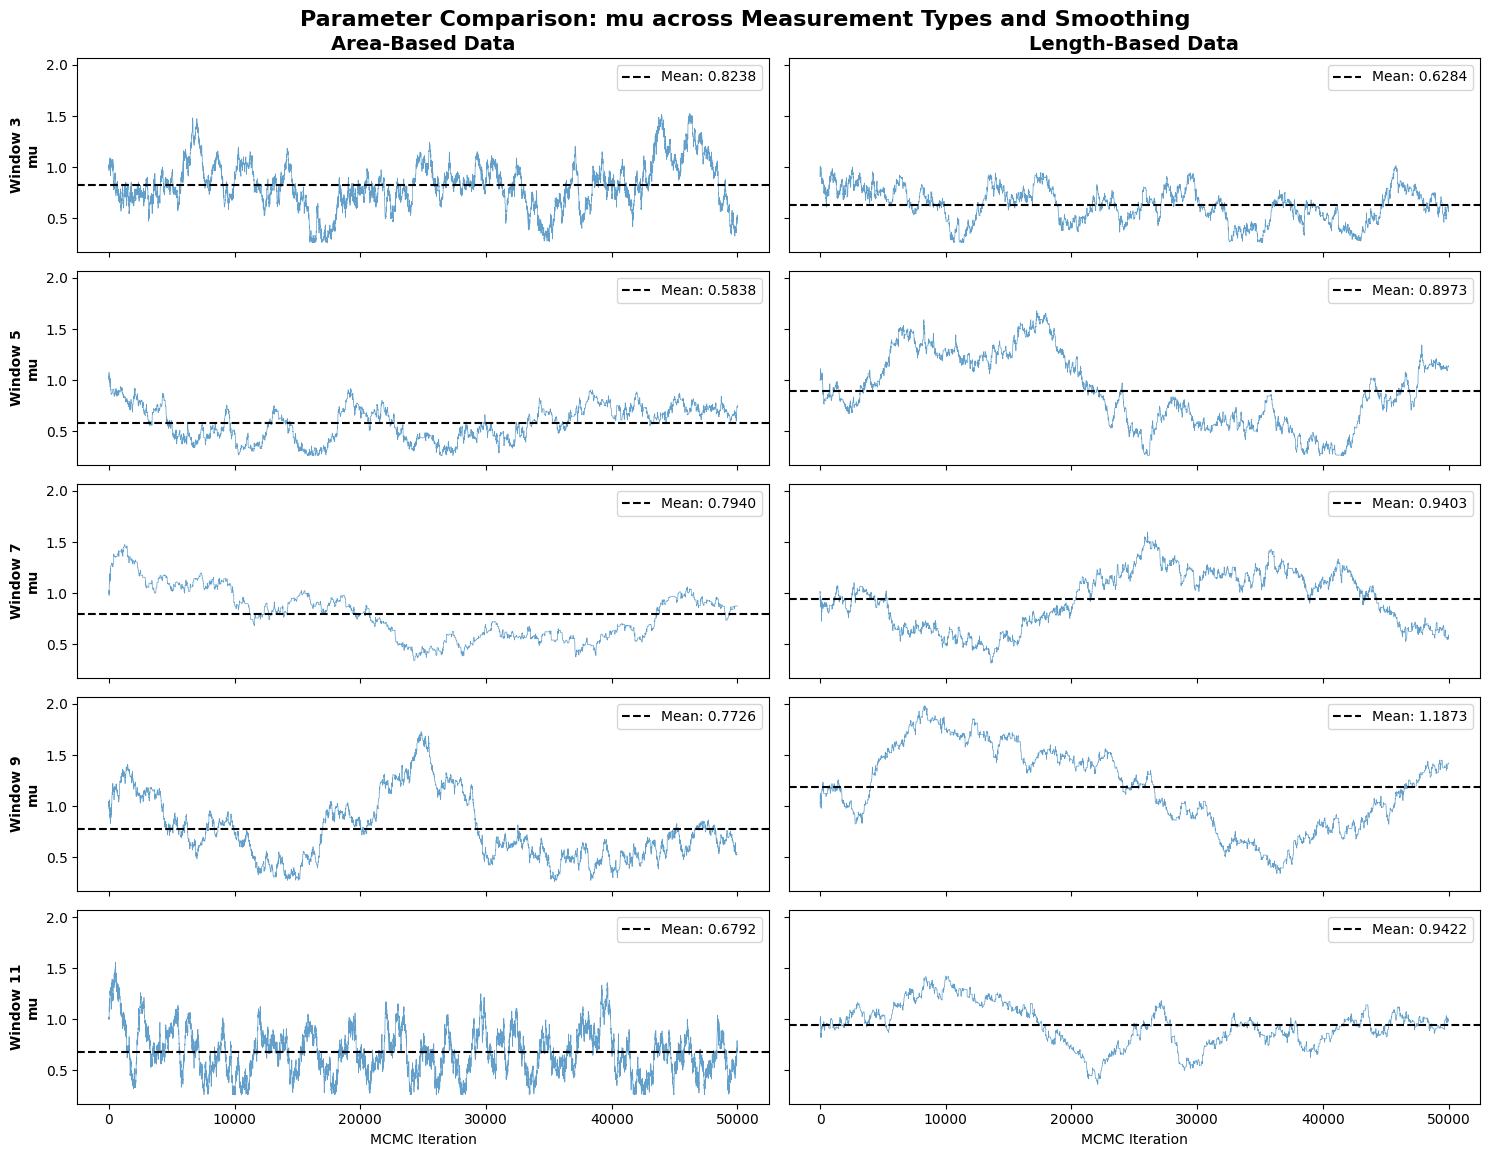

In [28]:
plot_mu(experimental_mcmc_results, smoothing_windows)

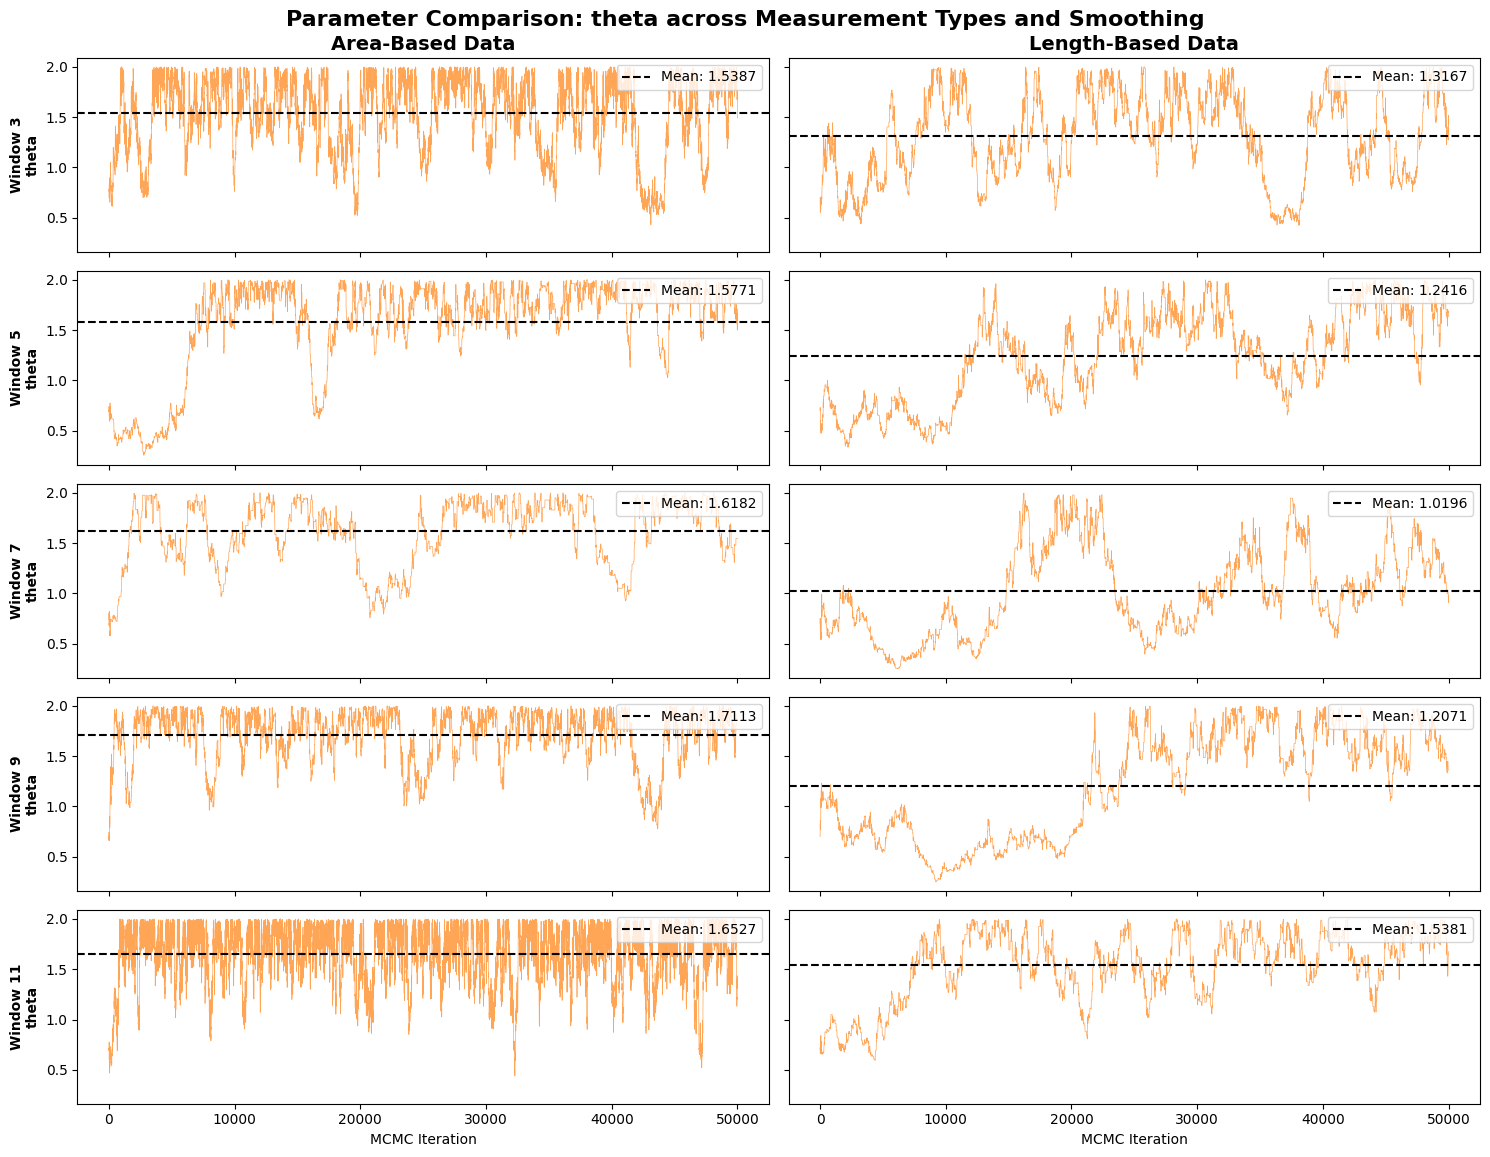

In [29]:
plot_theta(experimental_mcmc_results, smoothing_windows)

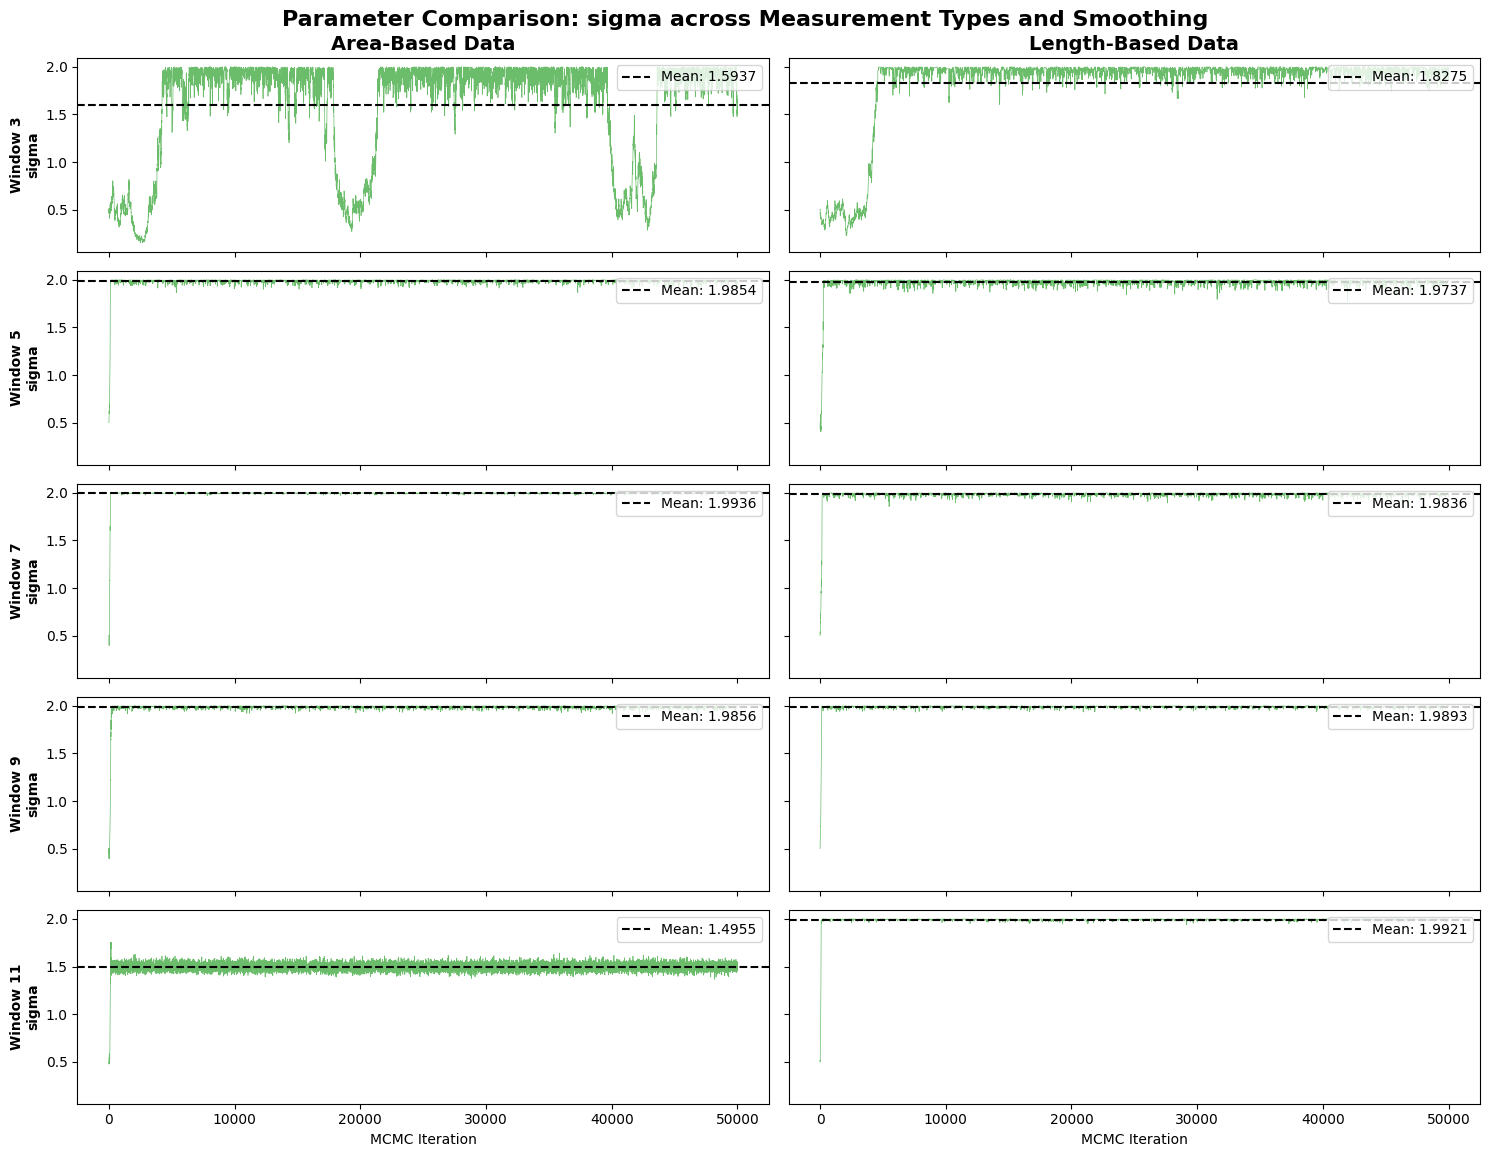

In [30]:
plot_sigma(experimental_mcmc_results, smoothing_windows)

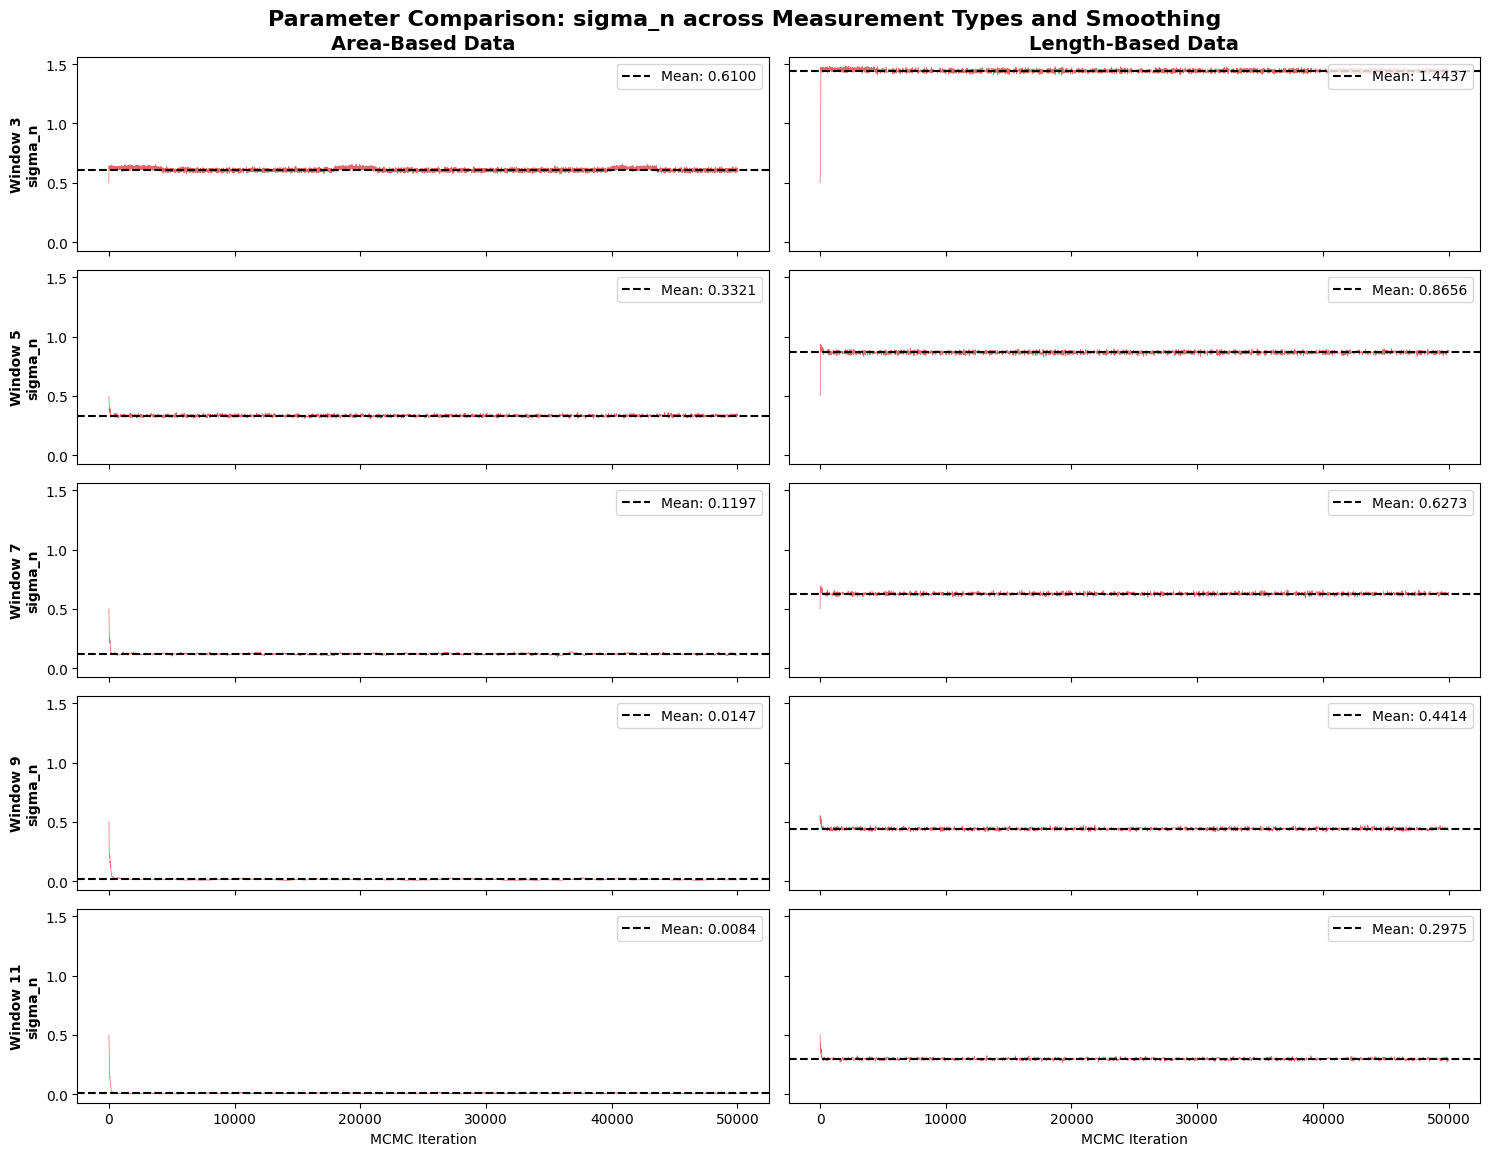

In [31]:
plot_sigma_noise(experimental_mcmc_results, smoothing_windows)

In [33]:
def reload_experimental_mcmc_results(smoothing_windows):
    mcmc_results = {
        'Area': {},
        'Length': {}
    }
    print("Searching hard drive for saved MCMC chains...")
    for window in smoothing_windows:
        area_file = f"Experimental_Area_Joint_MCMC_window_{window}.npz"
        length_file = f"Experimental_Length_Joint_MCMC_window_{window}.npz"
        if os.path.exists(area_file):
            area_data = np.load(area_file)
            mcmc_results['Area'][window] = {
                'chain': area_data['chain'],
                'logp': area_data['logp_chain'],
                'acc_rate': area_data['acc_rate']
            }
            print(f" Loaded: {area_file}")
        if os.path.exists(length_file):
            length_data = np.load(length_file)
            mcmc_results['Length'][window] = {
                'chain': length_data['chain'],
                'logp': length_data['logp_chain'],
                'acc_rate': length_data['acc_rate']
            }
            print(f" Loaded: {length_file}")
    print("\nSuccess! All MCMC data successfully restored to memory.")
    return mcmc_results

In [34]:
smoothing_windows = [3, 5, 7, 9, 11]
experimental_mcmc_results = reload_experimental_mcmc_results(smoothing_windows)

Searching hard drive for saved MCMC chains...
 Loaded: Experimental_Area_Joint_MCMC_window_3.npz
 Loaded: Experimental_Length_Joint_MCMC_window_3.npz
 Loaded: Experimental_Area_Joint_MCMC_window_5.npz
 Loaded: Experimental_Length_Joint_MCMC_window_5.npz
 Loaded: Experimental_Area_Joint_MCMC_window_7.npz
 Loaded: Experimental_Length_Joint_MCMC_window_7.npz
 Loaded: Experimental_Area_Joint_MCMC_window_9.npz
 Loaded: Experimental_Length_Joint_MCMC_window_9.npz
 Loaded: Experimental_Area_Joint_MCMC_window_11.npz
 Loaded: Experimental_Length_Joint_MCMC_window_11.npz

Success! All MCMC data successfully restored to memory.
